# Projeto Quantitativo — Estratégia de Breakout Donchian

Este notebook implementa e analisa uma estratégia quantitativa de **rompimento (breakout) baseada em Canais de Donchian** aplicada a um portfólio de 7 ações de tecnologia do S&P 500 (AAPL, MSFT, GOOGL, AMZN, META, NVDA, TSLA).

O fluxo de trabalho percorre:

1. Coleta de dados e visualização interativa;
2. Construção do sinal Donchian e validação visual;
3. Backtest vetorizado e cálculo de métricas (retorno, volatilidade, Sharpe);
4. Comparação com o benchmark livre de risco (CDI);
5. Análise de sensibilidade dos parâmetros de entrada/saída;
6. Teste de robustez em múltiplas janelas temporais;
7. Tentativa de filtro de tendência via SMA;
8. Ponderação dinâmica do portfólio por ATR inverso.


## 1. Configuração do ambiente


In [25]:
# !pip install yfinance mplfinance pandas_ta vectorbt -q

## 2. Coleta de dados e visualização interativa

Download dos preços OHLC via `yfinance` para os 7 ativos entre 01/01/2024 e 21/04/2026. Em seguida, é construído um gráfico de candlestick interativo com `plotly`, onde um menu dropdown permite alternar entre os ativos do portfólio.


In [26]:
import yfinance as yf
import datetime as dt
import plotly.graph_objects as go
from plotly.subplots import make_subplots

start_date = dt.datetime(2024, 1, 1)
end_date = dt.datetime(2026, 4, 21)
tickers = ["AAPL", "MSFT", "GOOGL", "AMZN", "META", "NVDA", "TSLA"]

data = yf.download(tickers, start=start_date, end=end_date, group_by='ticker')

fig = go.Figure()

for i, ticker in enumerate(tickers):
    df_plot = data[ticker].fillna(0)

    fig.add_trace(go.Candlestick(
        x=df_plot.index,
        open=df_plot['Open'],
        high=df_plot['High'],
        low=df_plot['Low'],
        close=df_plot['Close'],
        name=ticker,
        visible=(i == 0)
    ))

botoes = []
for i, ticker in enumerate(tickers):
    visibilidade = [False] * len(tickers)
    visibilidade[i] = True

    botao = dict(
        label=ticker,
        method="update",
        args=[{"visible": visibilidade},
              {"title": f"Análise Interativa: {ticker}"}]
    )
    botoes.append(botao)

fig.update_layout(
    updatemenus=[dict(
        active=0,
        buttons=botoes,
        x=0.01,
        y=1.15
    )],
    title=f"Análise Interativa: {tickers[0]}",
    xaxis_rangeslider_visible=False,
    template="plotly_dark",
    height=700
)

fig.show()

[*********************100%***********************]  7 of 7 completed


## 3. Construção do sinal Donchian

A função `gerar_sinais_donchian` calcula, para cada ativo, os canais superior (máxima dos últimos `periodo_compra` dias) e inferior (mínima dos últimos `periodo_venda` dias), deslocados em 1 dia para evitar *look-ahead bias*.

A regra do sinal é:

- **Entrada (compra)** — fechamento rompe acima do canal superior **apenas no dia do rompimento** (gatilho, não estado).
- **Saída** — fechamento rompe abaixo do canal inferior, também apenas no dia do evento.

A validação visual é feita sobre a MSFT (`tickers[1]`), plotando preço, canais e setas nos dias de sinal.


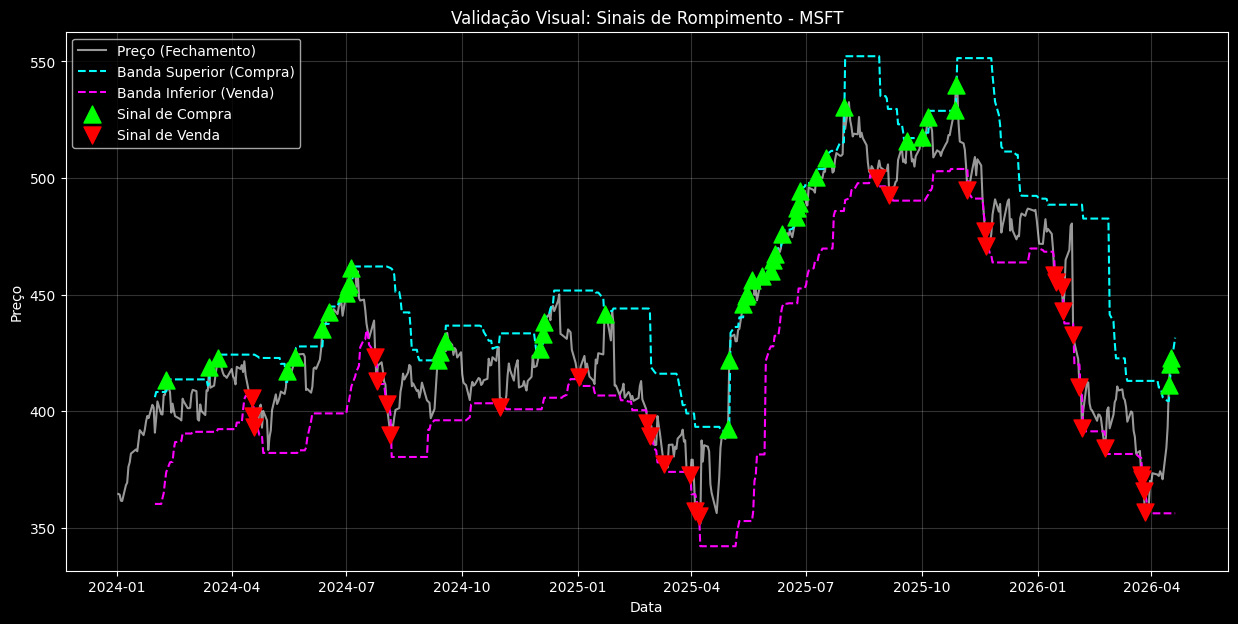

In [27]:
import matplotlib.pyplot as plt
import pandas as pd

def gerar_sinais_donchian(df_ativo, periodo_compra=20, periodo_venda=20):
    upperDon = df_ativo['High'].rolling(periodo_compra).max().shift(1)
    lowerDon = df_ativo['Low'].rolling(periodo_venda).min().shift(1)

    entradas_brutas = df_ativo['Close'] > upperDon
    saidas_brutas = df_ativo['Close'] < lowerDon

    entradas = entradas_brutas & (~entradas_brutas.shift(1).fillna(False))
    saidas = saidas_brutas & (~saidas_brutas.shift(1).fillna(False))

    return upperDon, lowerDon, entradas, saidas

ativo_teste = tickers[1]
df_teste = data[ativo_teste].copy()

upper, lower, entradas, saidas = gerar_sinais_donchian(df_teste)

plt.figure(figsize=(15, 7))
plt.style.use('dark_background')

plt.plot(df_teste.index, df_teste['Close'], label='Preço (Fechamento)', color='white', alpha=0.6)
plt.plot(df_teste.index, upper, label='Banda Superior (Compra)', color='cyan', linestyle='--')
plt.plot(df_teste.index, lower, label='Banda Inferior (Venda)', color='magenta', linestyle='--')

plt.scatter(df_teste.index[entradas], df_teste['Close'][entradas],
            marker='^', color='lime', label='Sinal de Compra', s=150, zorder=5)

plt.scatter(df_teste.index[saidas], df_teste['Close'][saidas],
            marker='v', color='red', label='Sinal de Venda', s=150, zorder=5)

plt.title(f"Validação Visual: Sinais de Rompimento - {ativo_teste}")
plt.xlabel("Data")
plt.ylabel("Preço")
plt.legend()
plt.grid(True, alpha=0.2)
plt.show()

## 4. Backtest vetorizado

O backtest é `long-only`: o sinal assume valores `1` (posicionado) ou `0` (fora do mercado). Dois pontos relevantes da implementação:

- `sinal.ffill()` propaga o estado da posição entre o dia da entrada e o dia da saída.
- O retorno diário da estratégia é calculado como `pct_change * Signal.shift(1)`, de forma que só se ganha se a posição já existia no início do pregão — outra proteção contra *look-ahead*.


In [28]:
import warnings
warnings.filterwarnings('ignore')

def backtest_donchian(tickers, data, periodo_compra=20, periodo_venda=20):
    resultados_diarios = {}

    for ticker in tickers:
        df = data[ticker].copy()

        _, _, entradas, saidas = gerar_sinais_donchian(
            df, periodo_compra, periodo_venda
        )


        df['Signal'] = 0
        df.loc[entradas, 'Signal'] = 1
        df.loc[saidas,   'Signal'] = 0

        sinal = pd.Series(index=df.index, dtype=float)
        sinal[entradas] = 1.0
        sinal[saidas]   = 0.0
        df['Signal'] = sinal.ffill().fillna(0)


        df['Daily_Return'] = df['Close'].pct_change() * df['Signal'].shift(1)

        df['Cumulative_Return'] = (df['Daily_Return'] + 1).cumprod() - 1

        resultados_diarios[ticker] = df[['Daily_Return', 'Cumulative_Return']]


    return resultados_diarios

resultados = backtest_donchian(tickers, data)

Só temos 2 tipos de Signal:

+1 → comprado (long):  você lucra quando o preço sobe

 0 → fora do mercado:  você não ganha nem perde nada

## 5. Curva de patrimônio — parâmetros iniciais (20/20)

Equity curve por ativo e para o portfólio igual-ponderado (média diária dos 7 retornos).


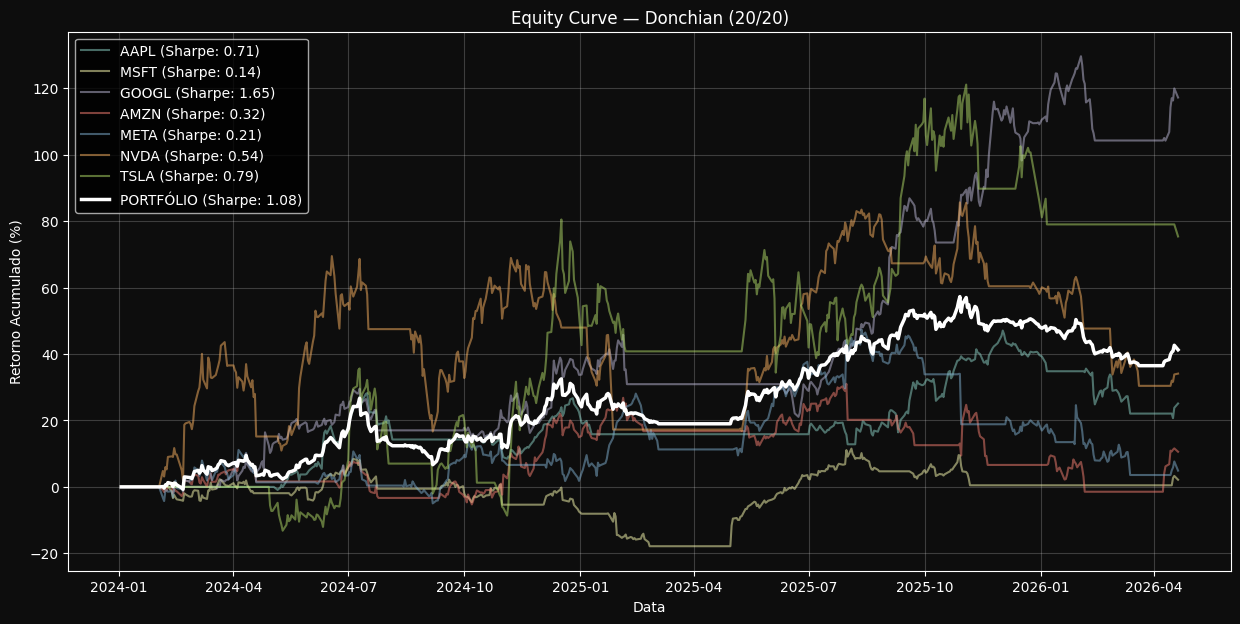

   Ticker  Retorno Total (%)  Sharpe
    GOOGL             117.25    1.65
     TSLA              75.41    0.79
PORTFÓLIO              41.29    1.08
     NVDA              34.11    0.54
     AAPL              25.11    0.71
     AMZN              10.59    0.32
     META               4.90    0.21
     MSFT               2.16    0.14


In [29]:
TRADING_DAYS = 252

fig, ax = plt.subplots(figsize=(15, 7))
fig.patch.set_facecolor('#0d0d0d')
ax.set_facecolor('#0d0d0d')

tabela = []
retornos_diarios_todos = []

for ticker, df in resultados.items():
    retornos = df['Daily_Return'].dropna()

    sharpe = (retornos.mean() / retornos.std()) * (TRADING_DAYS ** 0.5)
    retorno_total = df['Cumulative_Return'].iloc[-1] * 100

    tabela.append({'Ticker': ticker,
                   'Retorno Total (%)': round(retorno_total, 2),
                   'Sharpe': round(sharpe, 2)})

    retornos_diarios_todos.append(retornos)
    ax.plot(df.index, df['Cumulative_Return'] * 100, label=f"{ticker} (Sharpe: {sharpe:.2f})", alpha=0.5)

portfolio_returns = pd.concat(retornos_diarios_todos, axis=1).mean(axis=1)
portfolio_cumulative = (portfolio_returns + 1).cumprod() - 1
portfolio_sharpe = (portfolio_returns.mean() / portfolio_returns.std()) * (TRADING_DAYS ** 0.5)
tabela.append({'Ticker': 'PORTFÓLIO',
               'Retorno Total (%)': round(portfolio_cumulative.iloc[-1] * 100, 2),
               'Sharpe': round(portfolio_sharpe, 2)})
ax.plot(portfolio_cumulative.index, portfolio_cumulative * 100,
        label=f"PORTFÓLIO (Sharpe: {portfolio_sharpe:.2f})",
        color='white', linewidth=2.5)

ax.set_title("Equity Curve — Donchian (20/20)", color='white')
ax.set_xlabel("Data", color='white')
ax.set_ylabel("Retorno Acumulado (%)", color='white')
ax.tick_params(colors='white')
ax.legend()
ax.grid(True, alpha=0.2)
plt.show()

print(pd.DataFrame(tabela).sort_values('Retorno Total (%)', ascending=False).to_string(index=False))

### Resultado Donchian 20/20

No período de ~2,3 anos, o portfólio igual-ponderado com parâmetros Donchian 20/20 apresenta:

- **Retorno total:** 41,29%
- **Retorno anualizado:** 16,30%
- **Volatilidade anualizada:** 15,14%
- **Sharpe:** 1,08

Dispersão por ativo é elevada: GOOGL lidera com 117,25% (Sharpe 1,65), enquanto MSFT fica em apenas 2,16%. Isso sugere que a estratégia captura bem tendências longas, mas sofre com whipsaws em ativos menos tendenciais no período.


In [30]:
portfolio_returns_simples = pd.concat(
    [resultados[ticker]['Daily_Return'] for ticker in tickers], axis=1
).mean(axis=1).dropna()

ret_anual = portfolio_returns_simples.mean() * 252 * 100
vol_anual = portfolio_returns_simples.std() * (252 ** 0.5) * 100
sharpe = ret_anual / vol_anual

print("-" * 40)
print("RELATÓRIO DE PERFORMANCE DO PORTFÓLIO")
print("-" * 40)
print(f"Retorno Total no Período:    {(portfolio_cumulative.iloc[-1] * 100):.2f}%")
print(f"Retorno Médio Anualizado:    {ret_anual:.2f}%")
print(f"Volatilidade Anualizada:     {vol_anual:.2f}%")
print(f"Índice de Sharpe:            {sharpe:.2f}")
print("-" * 40)

----------------------------------------
RELATÓRIO DE PERFORMANCE DO PORTFÓLIO
----------------------------------------
Retorno Total no Período:    41.29%
Retorno Médio Anualizado:    16.30%
Volatilidade Anualizada:     15.14%
Índice de Sharpe:            1.08
----------------------------------------


## 6. Comparação com o CDI

O CDI é puxado diretamente da API do Banco Central (série 12) para servir de *benchmark* livre de risco.


In [31]:
import pandas as pd
import requests

def get_cdi(start='01/01/2024', end='22/04/2026'):

    url = f"https://api.bcb.gov.br/dados/serie/bcdata.sgs.12/dados?formato=json&dataInicial={start}&dataFinal={end}"

    response = requests.get(url)

    if response.status_code != 200:
        raise Exception("Erro na API do Banco Central")

    data = response.json()

    if len(data) == 0:
        raise Exception("API retornou vazio — verifique datas")

    df = pd.DataFrame(data)

    if 'data' not in df.columns or 'valor' not in df.columns:
        raise Exception(f"Formato inesperado: {df.columns}")

    df['data'] = pd.to_datetime(df['data'], dayfirst=True)
    df['valor'] = df['valor'].astype(float)

    df = df.set_index('data')

    df['cdi'] = df['valor'] / 100
    df['cdi_acumulado'] = (1 + df['cdi']).cumprod()

    return df

cdi_df = get_cdi()
cdi_df.tail()

,valor,cdi,cdi_acumulado
data,,,
2026-04-14,0.054266,0.000543,1.317236
2026-04-15,0.054266,0.000543,1.317951
2026-04-16,0.054266,0.000543,1.318666
2026-04-17,0.054266,0.000543,1.319382
2026-04-20,0.054266,0.000543,1.320098


In [32]:
import pandas as pd

def retorno_cdi_periodo(cdi_df, data_inicio, data_fim=None):
    df = cdi_df.copy().sort_index()

    data_inicio = pd.to_datetime(data_inicio)

    if data_fim is None:
        data_fim = df.index.max()
    else:
        data_fim = pd.to_datetime(data_fim)

    df_inicio = df[df.index >= data_inicio]
    if df_inicio.empty:
        raise ValueError("Não há dados de CDI a partir da data de início informada.")

    df_fim = df[df.index <= data_fim]
    if df_fim.empty:
        raise ValueError("Não há dados de CDI até a data final informada.")

    valor_inicio = df_inicio.iloc[0]['cdi_acumulado']
    valor_fim = df_fim.iloc[-1]['cdi_acumulado']

    retorno = (valor_fim / valor_inicio) - 1

    print(f"Data efetiva de entrada: {df_inicio.index[0].date()}")
    print(f"Data efetiva de saída:   {df_fim.index[-1].date()}")
    print(f"Retorno CDI no período: {retorno*100:.2f}%")

    return retorno
retorno = retorno_cdi_periodo(cdi_df, '2024-01-01')

Data efetiva de entrada: 2024-01-02
Data efetiva de saída:   2026-04-20
Retorno CDI no período: 31.95%


### Estratégia vs. CDI

No mesmo período (02/01/2024 a 20/04/2026), o **CDI acumulou 31,95%**, enquanto a estratégia Donchian 20/20 rendeu **41,29%**. A estratégia superou o CDI em ~9,3 pontos percentuais de retorno total, e ainda o faz assumindo risco de mercado (volatilidade de 15,14%). A comparação sugere valor marginal, mas não muito folgado — o que motiva a análise de sensibilidade a seguir.


## 7. Análise de sensibilidade dos parâmetros

Grid search sobre todas as combinações `(periodo_compra, periodo_venda)` de 5 a 50 (2.116 combinações). Para cada par, refaz o backtest completo e registra o Sharpe do portfólio.


In [33]:
resultados_sensibilidade = []

for periodo_compra in range(5, 51):
    for periodo_venda in range(5, 51):
        res = backtest_donchian(tickers, data, periodo_compra, periodo_venda)
        portfolio_returns = pd.concat(
            [df['Daily_Return'] for df in res.values()], axis=1
        ).mean(axis=1).dropna()
        sharpe = (portfolio_returns.mean() / portfolio_returns.std()) * (252 ** 0.5)
        resultados_sensibilidade.append((periodo_compra, periodo_venda, round(sharpe, 2)))

sens_df = pd.DataFrame(resultados_sensibilidade, columns=['Compra', 'Venda', 'Sharpe'])
sharpe_atual = sens_df[(sens_df['Compra'] == 20) & (sens_df['Venda'] == 20)]['Sharpe'].values[0]

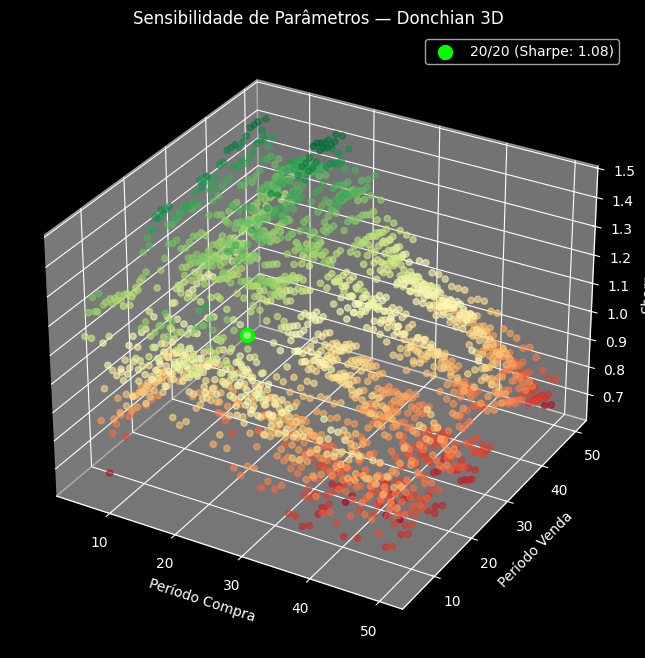

In [34]:
from mpl_toolkits.mplot3d import Axes3D

fig = plt.figure(figsize=(14, 8))
ax = fig.add_subplot(111, projection='3d')

ax.scatter(sens_df['Compra'], sens_df['Venda'], sens_df['Sharpe'],
           c=sens_df['Sharpe'], cmap='RdYlGn', s=20, alpha=0.6)

ax.scatter(20, 20, sharpe_atual, color='lime', s=100, zorder=5, label=f'20/20 (Sharpe: {sharpe_atual})')

ax.set_xlabel('Período Compra')
ax.set_ylabel('Período Venda')
ax.set_zlabel('Sharpe')
ax.set_title('Sensibilidade de Parâmetros — Donchian 3D')
ax.legend()
plt.show()

In [35]:
print("\nRANKING DE PARÂMETROS — DONCHIAN")
print("-" * 45)

ranking = sens_df.sort_values('Sharpe', ascending=False).reset_index(drop=True)
ranking.index += 1

posicao_atual = ranking[(ranking['Compra'] == 20) & (ranking['Venda'] == 20)].index[0]

print(ranking.to_string())
print("-" * 45)
print(f"\nNosso parâmetro atual (20/20) está na posição {posicao_atual} de {len(ranking)}")

print(f"\nSharpe médio de todas as combinações: {sens_df['Sharpe'].mean():.2f}")
print(f"Sharpe mediano de todas as combinações: {sens_df['Sharpe'].median():.2f}")
print(f"% de combinações com Sharpe > 1.0: {(sens_df['Sharpe'] > 1.0).mean()*100:.1f}%")


RANKING DE PARÂMETROS — DONCHIAN
---------------------------------------------
      Compra  Venda  Sharpe
1         16     45    1.45
2         16     44    1.45
3         17     45    1.44
4         17     44    1.44
5         16     46    1.44
6         17     50    1.43
7         16     50    1.43
8         16     47    1.43
9          5     46    1.43
10         5     47    1.43
11         5     48    1.43
12        17     48    1.43
13        16     48    1.43
14        17     47    1.43
15        17     46    1.43
16         5     50    1.42
17        16     43    1.42
18        16     41    1.41
19        16     42    1.41
20         5     42    1.41
21         5     41    1.41
22         5     40    1.41
23        17     43    1.41
24         5     45    1.41
25        17     33    1.40
26         6     22    1.40
27        17     42    1.40
28        17     41    1.40
29         6     33    1.40
30        16     33    1.40
31         5     44    1.40
32         5     43    1

A estratégia funciona melhor quando há assimetria entre entrada e saída, entradas rápidas capturam o início da tendência, enquanto saídas lentas permitem capturar a persistência do movimento.

### Ranking de parâmetros e escolha por robustez

O ranking bruto coloca o topo em `(16, 45)` com Sharpe 1,45 — bem acima do 1,08 de 20/20. Entretanto, escolher o pico do grid é um convite ao *overfitting*. Por isso, aplica-se um **escore de robustez**: para cada ponto, calcula-se a média de Sharpe de sua vizinhança (janela ±2 em cada eixo).


In [36]:
def robust_score(df, compra, venda, window=2):
    subset = df[
        (df["Compra"].between(compra-window, compra+window)) &
        (df["Venda"].between(venda-window, venda+window))
    ]
    return subset["Sharpe"].mean()

sens_df["Robustez"] = sens_df.apply(
    lambda row: robust_score(sens_df, row["Compra"], row["Venda"]), axis=1
)

best = sens_df.sort_values(by="Robustez", ascending=False).iloc[0]

print("Parâmetro mais robusto (melhor vizinhança):")
print(f"  Compra:   {int(best['Compra'])}")
print(f"  Venda:    {int(best['Venda'])}")
print(f"  Sharpe:   {best['Sharpe']}")
print(f"  Robustez: {best['Robustez']:.3f}")
print(f"\nNosso parâmetro original (20/20): Sharpe {sens_df[(sens_df['Compra']==20) & (sens_df['Venda']==20)]['Sharpe'].values[0]}, Robustez {sens_df[(sens_df['Compra']==20) & (sens_df['Venda']==20)]['Robustez'].values[0]:.3f}")

Parâmetro mais robusto (melhor vizinhança):
  Compra:   16
  Venda:    46
  Sharpe:   1.44
  Robustez: 1.385

Nosso parâmetro original (20/20): Sharpe 1.08, Robustez 1.095


### Parâmetro robusto escolhido: (16, 46)

- Sharpe pontual: **1,44**
- Sharpe médio da vizinhança (robustez): **1,385**

Comparado ao original (20/20): Sharpe 1,08, robustez 1,095. O novo ponto não só tem Sharpe maior como é cercado por vizinhos também bons — isto é, está em um **platô** do grid, não em um pico isolado. Parâmetros em platôs tendem a degradar menos out-of-sample.


## 8. Backtest com parâmetros otimizados (16/46)


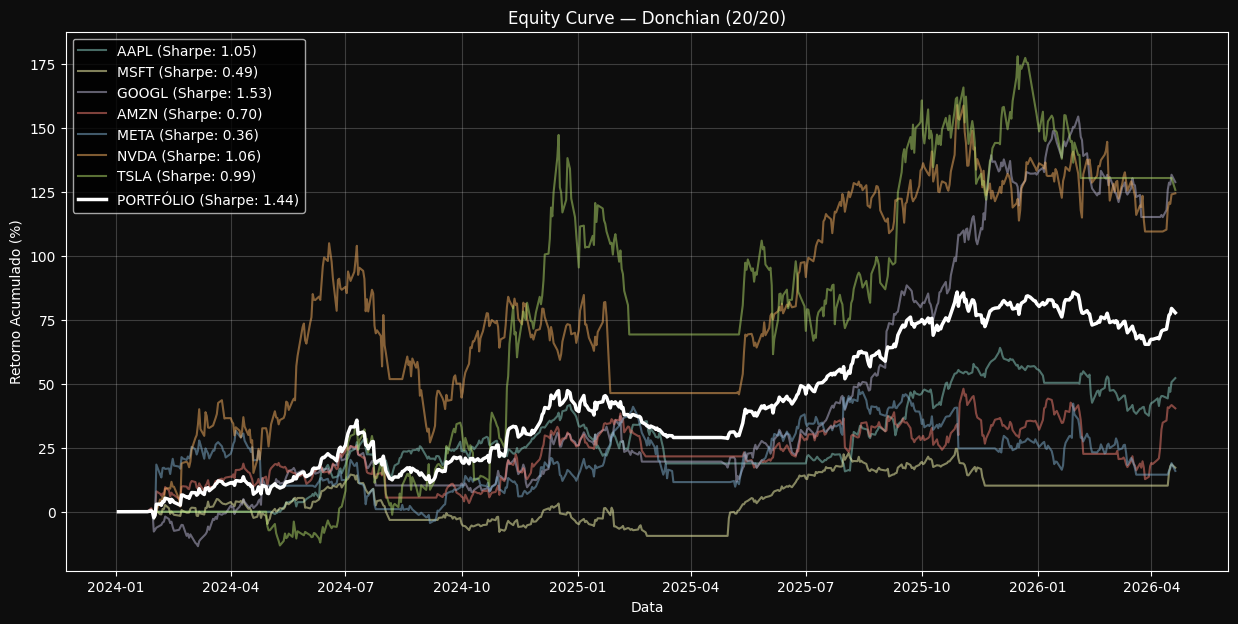

   Ticker  Retorno Total (%)  Sharpe
    GOOGL             128.84    1.53
     TSLA             125.77    0.99
     NVDA             124.45    1.06
PORTFÓLIO              77.78    1.44
     AAPL              52.23    1.05
     AMZN              40.41    0.70
     MSFT              17.20    0.49
     META              15.95    0.36


In [37]:
resultados_novos = backtest_donchian(tickers, data, 16, 46)

TRADING_DAYS = 252

fig, ax = plt.subplots(figsize=(15, 7))
fig.patch.set_facecolor('#0d0d0d')
ax.set_facecolor('#0d0d0d')

tabela = []
retornos_diarios_todos = []

for ticker, df in resultados_novos.items():
    retornos = df['Daily_Return'].dropna()

    sharpe = (retornos.mean() / retornos.std()) * (TRADING_DAYS ** 0.5)
    retorno_total = df['Cumulative_Return'].iloc[-1] * 100

    tabela.append({'Ticker': ticker,
                   'Retorno Total (%)': round(retorno_total, 2),
                   'Sharpe': round(sharpe, 2)})

    retornos_diarios_todos.append(retornos)
    ax.plot(df.index, df['Cumulative_Return'] * 100, label=f"{ticker} (Sharpe: {sharpe:.2f})", alpha=0.5)

portfolio_returns = pd.concat(retornos_diarios_todos, axis=1).mean(axis=1)
portfolio_cumulative = (portfolio_returns + 1).cumprod() - 1
portfolio_sharpe = (portfolio_returns.mean() / portfolio_returns.std()) * (TRADING_DAYS ** 0.5)
tabela.append({'Ticker': 'PORTFÓLIO',
               'Retorno Total (%)': round(portfolio_cumulative.iloc[-1] * 100, 2),
               'Sharpe': round(portfolio_sharpe, 2)})
ax.plot(portfolio_cumulative.index, portfolio_cumulative * 100,
        label=f"PORTFÓLIO (Sharpe: {portfolio_sharpe:.2f})",
        color='white', linewidth=2.5)

ax.set_title("Equity Curve — Donchian (20/20)", color='white')
ax.set_xlabel("Data", color='white')
ax.set_ylabel("Retorno Acumulado (%)", color='white')
ax.tick_params(colors='white')
ax.legend()
ax.grid(True, alpha=0.2)
plt.show()

print(pd.DataFrame(tabela).sort_values('Retorno Total (%)', ascending=False).to_string(index=False))

### Resultado com 16/46

- **Retorno total:** 77,78% (vs. 41,29% no 20/20)
- **Retorno anualizado:** 26,98%
- **Volatilidade anualizada:** 18,72%
- **Sharpe:** 1,44

A assimetria (entrada curta / saída longa) praticamente dobra o retorno total e eleva o Sharpe em ~33%. A volatilidade também cresce, mas menos que proporcionalmente ao retorno — daí a melhora do Sharpe. Intuitivamente, entradas rápidas capturam cedo o início da tendência, enquanto saídas lentas evitam *stop-outs* prematuros em pullbacks.


In [38]:
portfolio_returns_simples = pd.concat(
    [resultados_novos[ticker]['Daily_Return'] for ticker in tickers], axis=1
).mean(axis=1).dropna()

ret_anual = portfolio_returns_simples.mean() * 252 * 100
vol_anual = portfolio_returns_simples.std() * (252 ** 0.5) * 100
sharpe = ret_anual / vol_anual

print("-" * 40)
print("RELATÓRIO DE PERFORMANCE DO PORTFÓLIO")
print("-" * 40)
print(f"Retorno Total no Período:    {(portfolio_cumulative.iloc[-1] * 100):.2f}%")
print(f"Retorno Médio Anualizado:    {ret_anual:.2f}%")
print(f"Volatilidade Anualizada:     {vol_anual:.2f}%")
print(f"Índice de Sharpe:            {sharpe:.2f}")
print("-" * 40)

----------------------------------------
RELATÓRIO DE PERFORMANCE DO PORTFÓLIO
----------------------------------------
Retorno Total no Período:    77.78%
Retorno Médio Anualizado:    26.98%
Volatilidade Anualizada:     18.72%
Índice de Sharpe:            1.44
----------------------------------------


| Métrica | Donchian 20/20 | Donchian 16/46 |
|---|---|---|
| Retorno Total no Período | 41,29% | 77,78% |
| Retorno Médio Anualizado | 16,30% | 26,98% |
| Volatilidade Anualizada | 15,14% | 18,72% |
| Índice de Sharpe | 1,08 | 1,44 |


## 9. Robustez temporal — walk-forward em janelas móveis

Reexecução da estratégia 16/46 em 7 janelas históricas de ~2 anos cada, para verificar se o desempenho é genuíno ou concentrado em um regime específico.


In [39]:
import warnings
warnings.filterwarnings('ignore')

periodos = {
    '2019-2021': ('2019-01-01', '2021-01-01'),
    '2020-2022': ('2020-01-01', '2022-01-01'),
    '2021-2023': ('2021-01-01', '2023-01-01'),
    '2022-2024': ('2022-01-01', '2024-01-01'),
    '2023-2025': ('2023-01-01', '2025-01-01'),
    '2024-2026': ('2024-01-01', '2026-01-01'),
    'Período De Tempo Testado Antes': ('2024-01-01', '2026-04-21'),
}

resultados_tempo = []

for nome, (start, end) in periodos.items():
    data_periodo = yf.download(tickers, start=start, end=end, group_by='ticker')
    res = backtest_donchian(tickers, data_periodo, 16, 46)
    portfolio_returns = pd.concat(
        [df['Daily_Return'] for df in res.values()], axis=1
    ).mean(axis=1).dropna()
    sharpe = (portfolio_returns.mean() / portfolio_returns.std()) * (252 ** 0.5)
    retorno = (portfolio_returns + 1).prod() - 1
    resultados_tempo.append({'Período': nome,
                              'Retorno Total (%)': round(retorno * 100, 2),
                              'Sharpe': round(sharpe, 2)})

print('\n' + pd.DataFrame(resultados_tempo).to_string(index=False))

[*********************100%***********************]  7 of 7 completed
[*********************100%***********************]  7 of 7 completed
[*********************100%***********************]  7 of 7 completed
[*********************100%***********************]  7 of 7 completed
[*********************100%***********************]  7 of 7 completed
[*********************100%***********************]  7 of 7 completed
[*********************100%***********************]  7 of 7 completed



                       Período  Retorno Total (%)  Sharpe
                     2019-2021             169.85    2.08
                     2020-2022             101.55    1.37
                     2021-2023             -25.82   -0.58
                     2022-2024              10.14    0.32
                     2023-2025             119.06    1.88
                     2024-2026              81.36    1.65
Período De Tempo Testado Antes              77.78    1.44


Talvez valha falar algo como, num período recente de aproximadamente 6 anos, pandemia para cá, a estratégia se comportou bem relativamente bem por todos os períodos. Períodos notórios que aparentam ser pontos fora da curva são:

* 2019-2021: Período de Pandemia na qual o mercado de tecnologia num geral cresceu consideravelmente. Entretanto, retorno de 169.85% parece bastante inflado.
* 2021-2023: Período Pós Pandêmico. Tem um retorno extremamente baixo, o único negativo de -25.82%.

Os demais períodos, apesar de variarem bastante, tem valores de sharpe e retorno consideravelmente aceitáveis.

### Leitura dos períodos

| Período | Retorno | Sharpe |
|---|---|---|
| 2019–2021 | **169,85%** | 2,08 |
| 2020–2022 | 101,55% | 1,37 |
| 2021–2023 | **−25,82%** | −0,58 |
| 2022–2024 | 10,00% | 0,32 |
| 2023–2025 | 119,34% | 1,88 |
| 2024–2026 | 81,36% | 1,65 |
| Período testado | 77,78% | 1,44 |

A estratégia é consistente na maior parte das janelas, mas há dois pontos fora da curva:

- **2019–2021**: pandemia e afrouxamento monetário inflaram artificialmente o setor de tecnologia — um retorno de ~170% deve ser lido com ressalva, pois reflete um regime excepcional, não replicável.
- **2021–2023**: único período negativo, sob o aperto monetário pós-pandemia. Breakouts em mercado lateral/baixista geram muitos whipsaws, e a estratégia é especialmente vulnerável nesse regime.

Nos 5 períodos restantes o Sharpe é estável entre 0,32 e 1,88, reforçando que o modelo **funciona em tendência e falha em lateralização**.


## 10. Tentativa de filtro de tendência (SMA)

Hipótese: adicionar um filtro `Close > SMA(200)` sobre a entrada deveria eliminar breakouts em mercados bear e melhorar o Sharpe.


In [40]:
def gerar_sinais_donchian_complexo(df_ativo, periodo_compra=16, periodo_venda=46, periodo_sma=200):
    upperDon = df_ativo['High'].rolling(periodo_compra).max().shift(1)
    lowerDon = df_ativo['Low'].rolling(periodo_venda).min().shift(1)

    sma = df_ativo['Close'].rolling(periodo_sma).mean()
    filtro_tendencia = df_ativo['Close'] > sma

    entradas_brutas = (df_ativo['Close'] > upperDon) & filtro_tendencia
    saidas_brutas = df_ativo['Close'] < lowerDon

    entradas = entradas_brutas & (~entradas_brutas.shift(1).fillna(False))
    saidas = saidas_brutas & (~saidas_brutas.shift(1).fillna(False))

    return upperDon, lowerDon, entradas, saidas

In [41]:
import warnings
warnings.filterwarnings('ignore')

def backtest_donchian_complexo(tickers, data, periodo_compra=16, periodo_venda=46, periodo_sma=200):
    resultados_diarios = {}

    for ticker in tickers:
        df = data[ticker].copy()

        _, _, entradas, saidas = gerar_sinais_donchian_complexo(df, periodo_compra, periodo_venda, periodo_sma)

        df['Signal'] = 0
        df.loc[entradas, 'Signal'] = 1
        df.loc[saidas,   'Signal'] = 0

        sinal = pd.Series(index=df.index, dtype=float)
        sinal[entradas] = 1.0
        sinal[saidas]   = 0.0
        df['Signal'] = sinal.ffill().fillna(0)

        df['Daily_Return'] = df['Close'].pct_change() * df['Signal'].shift(1)
        df['Cumulative_Return'] = (df['Daily_Return'] + 1).cumprod() - 1
        resultados_diarios[ticker] = df[['Daily_Return', 'Cumulative_Return']]

    return resultados_diarios

resultados_complexo = backtest_donchian_complexo(tickers, data, periodo_sma=200)

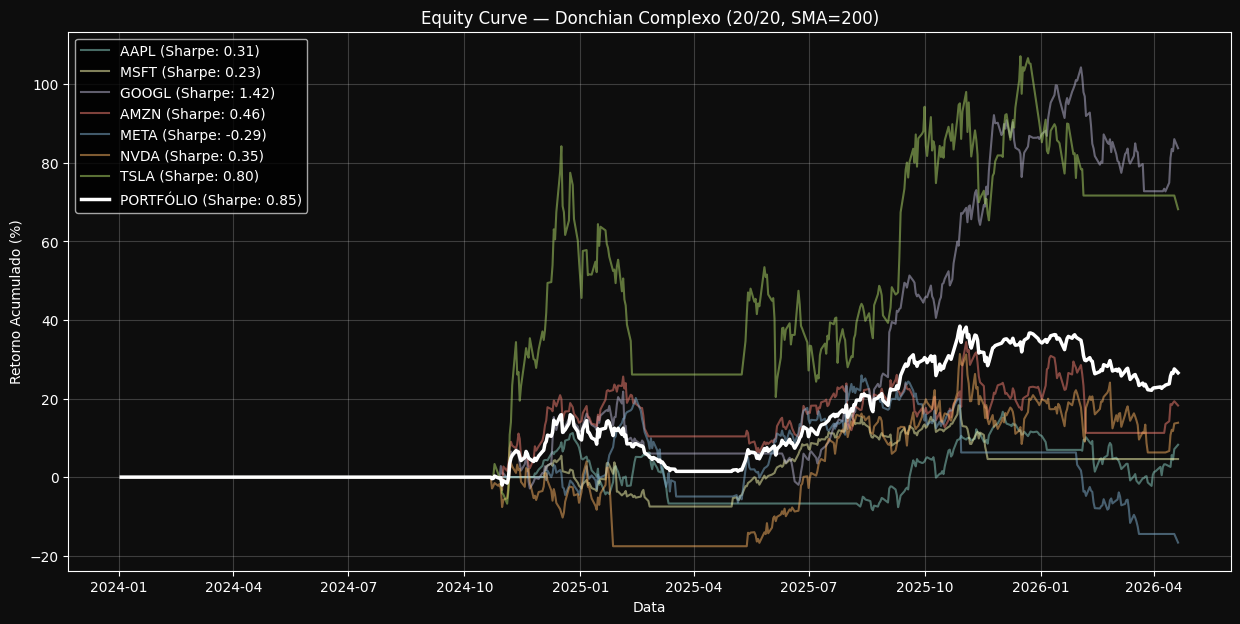

   Ticker  Retorno Total (%)  Sharpe
    GOOGL              83.71    1.42
     TSLA              68.19    0.80
PORTFÓLIO              26.54    0.85
     AMZN              18.22    0.46
     NVDA              13.84    0.35
     AAPL               8.23    0.31
     MSFT               4.60    0.23
     META             -16.67   -0.29


In [42]:
TRADING_DAYS = 252

fig, ax = plt.subplots(figsize=(15, 7))
fig.patch.set_facecolor('#0d0d0d')
ax.set_facecolor('#0d0d0d')

tabela = []
retornos_diarios_todos = []

for ticker, df in resultados_complexo.items():
    retornos = df['Daily_Return'].dropna()

    sharpe = (retornos.mean() / retornos.std()) * (TRADING_DAYS ** 0.5)
    retorno_total = df['Cumulative_Return'].iloc[-1] * 100

    tabela.append({'Ticker': ticker,
                   'Retorno Total (%)': round(retorno_total, 2),
                   'Sharpe': round(sharpe, 2)})

    retornos_diarios_todos.append(retornos)
    ax.plot(df.index, df['Cumulative_Return'] * 100, label=f"{ticker} (Sharpe: {sharpe:.2f})", alpha=0.5)

portfolio_returns = pd.concat(retornos_diarios_todos, axis=1).mean(axis=1)
portfolio_cumulative = (portfolio_returns + 1).cumprod() - 1
portfolio_sharpe = (portfolio_returns.mean() / portfolio_returns.std()) * (TRADING_DAYS ** 0.5)
tabela.append({'Ticker': 'PORTFÓLIO',
               'Retorno Total (%)': round(portfolio_cumulative.iloc[-1] * 100, 2),
               'Sharpe': round(portfolio_sharpe, 2)})
ax.plot(portfolio_cumulative.index, portfolio_cumulative * 100,
        label=f"PORTFÓLIO (Sharpe: {portfolio_sharpe:.2f})",
        color='white', linewidth=2.5)

ax.set_title("Equity Curve — Donchian Complexo (20/20, SMA=200)", color='white')
ax.set_xlabel("Data", color='white')
ax.set_ylabel("Retorno Acumulado (%)", color='white')
ax.tick_params(colors='white')
ax.legend()
ax.grid(True, alpha=0.2)
plt.show()

print(pd.DataFrame(tabela).sort_values('Retorno Total (%)', ascending=False).to_string(index=False))

### Resultado Donchian + SMA(200)

- **Retorno total:** 26,54% (vs. 77,78% sem SMA)
- **Sharpe:** 0,85 (vs. 1,44 sem SMA)

O filtro **piorou significativamente** tanto o retorno quanto o Sharpe. A seguir, varremos o período da SMA para checar se 200 foi uma má escolha.


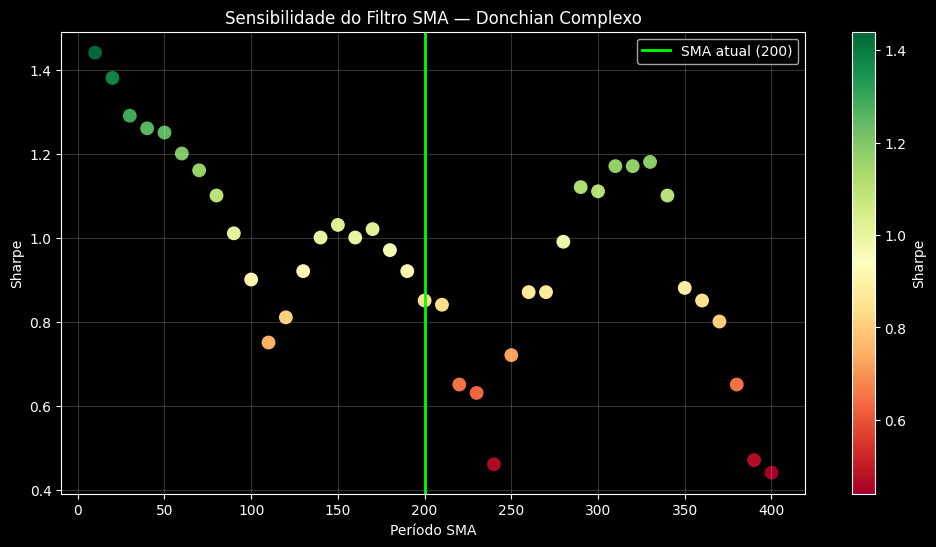

 SMA  Sharpe
  10    1.44
  20    1.38
  30    1.29
  40    1.26
  50    1.25
  60    1.20
 330    1.18
 310    1.17
 320    1.17
  70    1.16
 290    1.12
 300    1.11
  80    1.10
 340    1.10
 150    1.03
 170    1.02
  90    1.01
 140    1.00
 160    1.00
 280    0.99
 180    0.97
 190    0.92
 130    0.92
 100    0.90
 350    0.88
 260    0.87
 270    0.87
 200    0.85
 360    0.85
 210    0.84
 120    0.81
 370    0.80
 110    0.75
 250    0.72
 220    0.65
 380    0.65
 230    0.63
 390    0.47
 240    0.46
 400    0.44
   0     NaN


In [43]:
resultados_sma = []

for periodo_sma in range(0, 401, 10):
    res = backtest_donchian_complexo(tickers, data, periodo_sma=periodo_sma)
    portfolio_returns = pd.concat(
        [df['Daily_Return'] for df in res.values()], axis=1
    ).mean(axis=1).dropna()
    sharpe = (portfolio_returns.mean() / portfolio_returns.std()) * (252 ** 0.5)
    resultados_sma.append((periodo_sma, round(sharpe, 2)))

sma_df = pd.DataFrame(resultados_sma, columns=['SMA', 'Sharpe'])

plt.figure(figsize=(12, 6))
plt.style.use('dark_background')
plt.scatter(sma_df['SMA'], sma_df['Sharpe'], c=sma_df['Sharpe'], cmap='RdYlGn', s=80)
plt.axvline(200, color='lime', linewidth=2, label='SMA atual (200)')
plt.colorbar(label='Sharpe')
plt.title('Sensibilidade do Filtro SMA — Donchian Complexo')
plt.xlabel('Período SMA')
plt.ylabel('Sharpe')
plt.legend()
plt.grid(True, alpha=0.2)
plt.show()

print(sma_df.sort_values('Sharpe', ascending=False).to_string(index=False))

### Sensibilidade da SMA

A varredura (SMA de 0 a 400) mostra que **quanto menor a SMA, melhor o Sharpe**: SMA(10) → Sharpe 1,44; SMA(200) → 0,85; SMA(400) → 0,44. Ou seja, a melhor SMA é aquela que praticamente não filtra nada.

Isso é um veredicto claro: o filtro SMA é **redundante** com o próprio sinal Donchian. O canal superior já é, implicitamente, um indicador de tendência de curto prazo — sobrepor uma SMA longa apenas adiciona *lag* e elimina entradas válidas.


In [44]:
import warnings
warnings.filterwarnings('ignore')

periodos = {
    '2019-2021': ('2019-01-01', '2021-01-01'),
    '2020-2022': ('2020-01-01', '2022-01-01'),
    '2021-2023': ('2021-01-01', '2023-01-01'),
    '2022-2024': ('2022-01-01', '2024-01-01'),
    '2023-2025': ('2023-01-01', '2025-01-01'),
    '2024-2026': ('2024-01-01', '2026-01-01'),
    'Período De Tempo Testado Antes': ('2024-01-01', '2026-04-21'),
}

resultados_tempo = []

for nome, (start, end) in periodos.items():
    data_periodo = yf.download(tickers, start=start, end=end, group_by='ticker')
    res = backtest_donchian_complexo(tickers, data_periodo)
    portfolio_returns = pd.concat(
        [df['Daily_Return'] for df in res.values()], axis=1
    ).mean(axis=1).dropna()
    sharpe = (portfolio_returns.mean() / portfolio_returns.std()) * (252 ** 0.5)
    retorno = (portfolio_returns + 1).prod() - 1
    resultados_tempo.append({'Período': nome,
                              'Retorno Total (%)': round(retorno * 100, 2),
                              'Sharpe': round(sharpe, 2)})

print('\n' + pd.DataFrame(resultados_tempo).to_string(index=False))

[*********************100%***********************]  7 of 7 completed
[*********************100%***********************]  7 of 7 completed
[*********************100%***********************]  7 of 7 completed
[*********************100%***********************]  7 of 7 completed
[*********************100%***********************]  7 of 7 completed
[*********************100%***********************]  7 of 7 completed
[*********************100%***********************]  7 of 7 completed



                       Período  Retorno Total (%)  Sharpe
                     2019-2021             121.88    1.87
                     2020-2022              38.09    1.15
                     2021-2023             -23.17   -0.92
                     2022-2024              41.43    1.30
                     2023-2025              50.90    1.40
                     2024-2026              34.67    1.18
Período De Tempo Testado Antes              26.54    0.85


A introdução do filtro de média móvel reduziu tanto o retorno quanto o Sharpe, sugerindo que o filtro foi excessivamente restritivo e eliminou oportunidades válidas. Isso indica que o modelo original já capturava adequadamente os sinais de tendência, e que a adição de complexidade não necessariamente melhora o desempenho.

## 11. Posicionamento dinâmico por volatilidade

Em vez de pesos iguais (1/7 por ativo), testamos pesos proporcionais a `1/ATR_i`. A ideia é que ativos mais voláteis recebam menos peso, normalizando a contribuição de risco de cada posição (abordagem *inverse volatility weighting*).

O ATR é calculado com *True Range* de 20 dias, deslocado em 1 dia para evitar look-ahead.


In [45]:
def calcular_atr(df_ativo, periodo=20):
    high = df_ativo['High']
    low = df_ativo['Low']
    close = df_ativo['Close']

    tr1 = high - low
    tr2 = (high - close.shift(1)).abs()
    tr3 = (low - close.shift(1)).abs()
    true_range = pd.concat([tr1, tr2, tr3], axis=1).max(axis=1)

    return true_range.rolling(periodo).mean()

atr_matrix = pd.DataFrame({
    ticker: calcular_atr(data[ticker]) for ticker in tickers
}).shift(1)

inv_atr = 1 / atr_matrix
pesos_atr = inv_atr.div(inv_atr.sum(axis=1), axis=0)

print("Exemplo de pesos ATR (últimos 3 dias):")
print(pesos_atr.tail(3).round(3).to_string())

Exemplo de pesos ATR (últimos 3 dias):
             AAPL   MSFT  GOOGL   AMZN   META   NVDA   TSLA
Date                                                       
2026-04-16  0.202  0.126  0.136  0.178  0.055  0.228  0.075
2026-04-17  0.202  0.125  0.136  0.179  0.055  0.226  0.075
2026-04-20  0.198  0.123  0.138  0.178  0.056  0.232  0.075


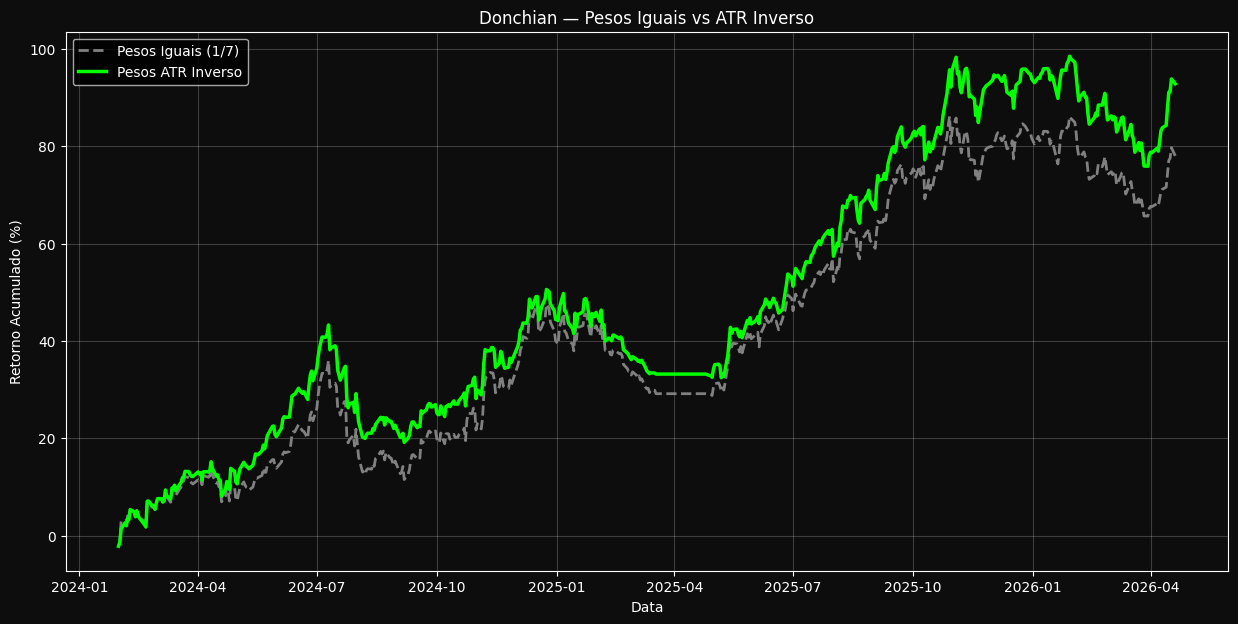


--- Pesos Iguais ---
Retorno Total:        77.99%
Retorno Anualizado:   27.95%
Volatilidade:         19.03%
Sharpe:               1.47

--- ATR Inverso ---
Retorno Total:        92.79%
Retorno Anualizado:   31.43%
Volatilidade:         18.26%
Sharpe:               1.72


In [46]:
ret_matrix_donchian = pd.concat(
    [resultados_novos[t]['Daily_Return'] for t in tickers], axis=1
).dropna()
ret_matrix_donchian.columns = tickers

pesos_alinhados = pesos_atr.reindex(ret_matrix_donchian.index).dropna()
ret_alinhados = ret_matrix_donchian.reindex(pesos_alinhados.index)

portfolio_returns_atr = (ret_alinhados * pesos_alinhados).sum(axis=1)
portfolio_cumulative_atr = (portfolio_returns_atr + 1).cumprod() - 1

portfolio_returns_igual = ret_alinhados.mean(axis=1)
portfolio_cumulative_igual = (portfolio_returns_igual + 1).cumprod() - 1

fig, ax = plt.subplots(figsize=(15, 7))
fig.patch.set_facecolor('#0d0d0d')
ax.set_facecolor('#0d0d0d')

ax.plot(portfolio_cumulative_igual.index, portfolio_cumulative_igual * 100,
        label='Pesos Iguais (1/7)', color='gray', linewidth=2, linestyle='--')
ax.plot(portfolio_cumulative_atr.index, portfolio_cumulative_atr * 100,
        label='Pesos ATR Inverso', color='lime', linewidth=2.5)

ax.set_title("Donchian — Pesos Iguais vs ATR Inverso", color='white')
ax.set_xlabel("Data", color='white')
ax.set_ylabel("Retorno Acumulado (%)", color='white')
ax.tick_params(colors='white')
ax.legend()
ax.grid(True, alpha=0.2)
plt.show()

for nome, ret in [('Pesos Iguais', portfolio_returns_igual), ('ATR Inverso', portfolio_returns_atr)]:
    r = ret.dropna()
    ret_anual = r.mean() * 252 * 100
    vol_anual = r.std() * (252 ** 0.5) * 100
    sharpe = ret_anual / vol_anual
    retorno_total = (r + 1).prod() - 1
    print(f"\n--- {nome} ---")
    print(f"Retorno Total:        {retorno_total*100:.2f}%")
    print(f"Retorno Anualizado:   {ret_anual:.2f}%")
    print(f"Volatilidade:         {vol_anual:.2f}%")
    print(f"Sharpe:               {sharpe:.2f}")

### Pesos Iguais vs. ATR Inverso

| Métrica | Pesos Iguais | ATR Inverso |
|---|---|---|
| Retorno total | 77,99% | **92,79%** |
| Retorno anualizado | 27,95% | **31,43%** |
| Volatilidade anualizada | 19,03% | **18,26%** |
| Sharpe | 1,47 | **1,72** |

O ATR inverso **melhora simultaneamente retorno e volatilidade**, elevando o Sharpe de 1,47 para 1,72 (+17%). Isso confirma o valor da ponderação por risco: ativos como TSLA, que são voláteis e com Sharpe médio, recebem menos peso, enquanto ativos mais estáveis têm maior influência no portfólio.


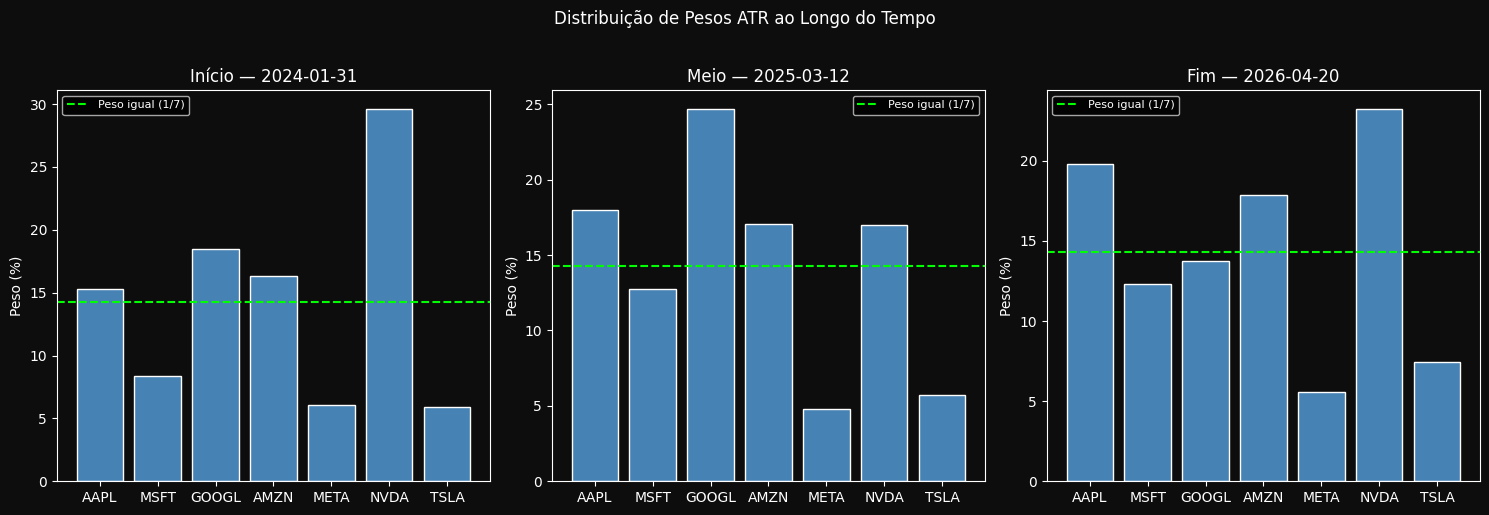

In [47]:
idx_inicio = pesos_alinhados.index[0]
idx_meio = pesos_alinhados.index[len(pesos_alinhados) // 2]
idx_fim = pesos_alinhados.index[-1]

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
fig.patch.set_facecolor('#0d0d0d')

for ax, idx, titulo in zip(axes,
                            [idx_inicio, idx_meio, idx_fim],
                            ['Início', 'Meio', 'Fim']):
    ax.set_facecolor('#0d0d0d')
    pesos_dia = pesos_alinhados.loc[idx]
    bars = ax.bar(tickers, pesos_dia * 100, color='steelblue', edgecolor='white')
    ax.axhline(100/len(tickers), color='lime', linestyle='--', label='Peso igual (1/7)')
    ax.set_title(f'{titulo} — {idx.date()}', color='white')
    ax.set_ylabel('Peso (%)', color='white')
    ax.tick_params(colors='white')
    ax.legend(fontsize=8)

plt.suptitle('Distribuição de Pesos ATR ao Longo do Tempo', color='white', y=1.02)
plt.tight_layout()
plt.show()

### Sensibilidade do período ATR

Varredura do período ATR de 5 a 100 dias para verificar se a escolha original (20) é robusta.


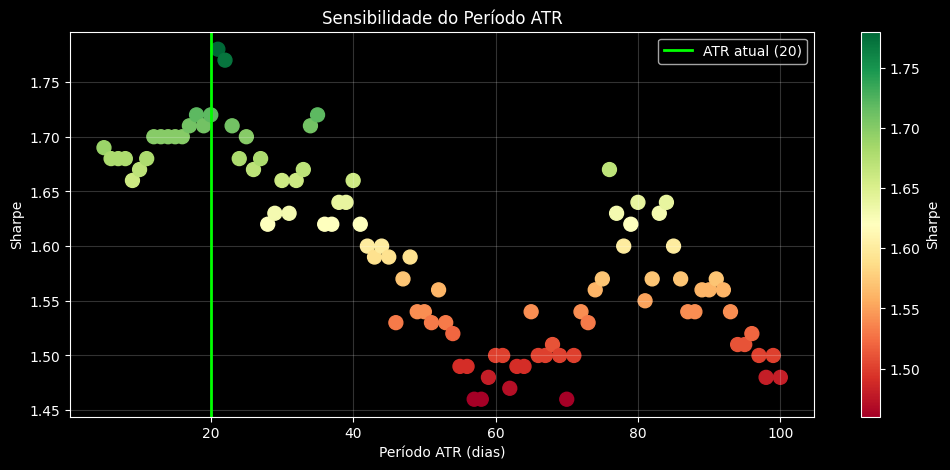

 Período ATR  Retorno Total (%)  Sharpe
          21              96.72    1.78
          22              96.00    1.77
          20              92.79    1.72
          35              89.41    1.72
          18              92.73    1.72
          34              88.59    1.71
          23              90.57    1.71
          17              92.33    1.71
          19              91.81    1.71
          25              89.95    1.70
          12              91.38    1.70
          13              91.25    1.70
          14              91.59    1.70
          15              91.62    1.70
          16              91.79    1.70
           5              92.02    1.69
           7              91.40    1.68
          24              88.13    1.68
          27              87.65    1.68
          11              90.37    1.68
           6              91.52    1.68
           8              91.16    1.68
          10              89.70    1.67
          26              86.98    1.67


In [48]:
resultados_sens_atr = []

for periodo_atr in range(5, 101, 1):
    atr_s = pd.DataFrame({
        t: calcular_atr(data[t], periodo=periodo_atr) for t in tickers
    }).shift(1)
    inv_atr_s = 1 / atr_s
    pesos_s = inv_atr_s.div(inv_atr_s.sum(axis=1), axis=0)
    pesos_s = pesos_s.reindex(ret_matrix_donchian.index).dropna()
    ret_s = ret_matrix_donchian.reindex(pesos_s.index)

    portfolio_s = (ret_s * pesos_s).sum(axis=1)
    sharpe = (portfolio_s.mean() / portfolio_s.std()) * (252 ** 0.5)
    retorno = (portfolio_s + 1).prod() - 1
    resultados_sens_atr.append({'Período ATR': periodo_atr,
                                 'Retorno Total (%)': round(retorno * 100, 2),
                                 'Sharpe': round(sharpe, 2)})

sens_atr_df = pd.DataFrame(resultados_sens_atr)

plt.figure(figsize=(12, 5))
plt.style.use('dark_background')
plt.scatter(sens_atr_df['Período ATR'], sens_atr_df['Sharpe'],
            c=sens_atr_df['Sharpe'], cmap='RdYlGn', s=100)
plt.axvline(20, color='lime', linewidth=2, label='ATR atual (20)')
plt.colorbar(label='Sharpe')
plt.title('Sensibilidade do Período ATR')
plt.xlabel('Período ATR (dias)')
plt.ylabel('Sharpe')
plt.legend()
plt.grid(True, alpha=0.2)
plt.show()

print(sens_atr_df.sort_values('Sharpe', ascending=False).to_string(index=False))

### Robustez temporal com pesos ATR


In [49]:
periodos = {
    '2019-2021': ('2019-01-01', '2021-01-01'),
    '2020-2022': ('2020-01-01', '2022-01-01'),
    '2021-2023': ('2021-01-01', '2023-01-01'),
    '2022-2024': ('2022-01-01', '2024-01-01'),
    '2023-2025': ('2023-01-01', '2025-01-01'),
    '2024-2026': ('2024-01-01', '2026-01-01'),
    'Período Testado': ('2024-01-01', '2026-04-21'),
}

resultados_tempo_atr = []

for nome, (start, end) in periodos.items():
    data_periodo = yf.download(tickers, start=start, end=end, group_by='ticker')
    res = backtest_donchian(tickers, data_periodo, 16, 46)

    ret_matrix_p = pd.concat(
        [res[t]['Daily_Return'] for t in tickers], axis=1
    ).dropna()
    ret_matrix_p.columns = tickers

    atr_p = pd.DataFrame({
        t: calcular_atr(data_periodo[t]) for t in tickers
    }).shift(1)
    inv_atr_p = 1 / atr_p
    pesos_p = inv_atr_p.div(inv_atr_p.sum(axis=1), axis=0)
    pesos_p = pesos_p.reindex(ret_matrix_p.index).dropna()
    ret_p = ret_matrix_p.reindex(pesos_p.index)

    portfolio_p = (ret_p * pesos_p).sum(axis=1)
    sharpe = (portfolio_p.mean() / portfolio_p.std()) * (252 ** 0.5)
    retorno = (portfolio_p + 1).prod() - 1

    resultados_tempo_atr.append({'Período': nome,
                                  'Retorno Total (%)': round(retorno * 100, 2),
                                  'Sharpe': round(sharpe, 2)})

print('\n' + pd.DataFrame(resultados_tempo_atr).to_string(index=False))

[*********************100%***********************]  7 of 7 completed
[*********************100%***********************]  7 of 7 completed
[*********************100%***********************]  7 of 7 completed
[*********************100%***********************]  7 of 7 completed
[*********************100%***********************]  7 of 7 completed
[*********************100%***********************]  7 of 7 completed
[*********************100%***********************]  7 of 7 completed



        Período  Retorno Total (%)  Sharpe
      2019-2021             202.73    1.98
      2020-2022             164.81    1.67
      2021-2023             -11.89   -0.07
      2022-2024              22.04    0.49
      2023-2025             168.54    2.24
      2024-2026              93.77    1.94
Período Testado              92.79    1.72


## 12. Conclusões finais

### Sobre a estratégia

1. **O sinal Donchian funciona para este universo de ativos**, superando o CDI no período testado mesmo com parâmetros ingênuos. Na versão ingênua (20/20), o Sharpe foi 1,08 e o retorno 41,29% contra 31,95% do CDI.

2. **A assimetria entrada-curta / saída-longa é o parâmetro dominante.** A migração de (20,20) para (16,46), guiada por robustez de vizinhança (e não pelo pico do grid), quase dobrou o retorno total (41,29% → 77,78%) e elevou o Sharpe em ~33%. Entradas rápidas capturam o início da tendência; saídas lentas evitam whipsaws em pullbacks.

3. **A ponderação por ATR inverso é a melhoria mais limpa do estudo.** Melhorou retorno *e* reduziu volatilidade ao mesmo tempo, resultando em Sharpe 1,72 (versus 1,47 com pesos iguais). A estabilidade ao variar o período do ATR (picos entre 18–35 dias) indica que o ganho não é overfit de parâmetro.

4. **O filtro SMA de tendência *não* agregou valor.** A varredura mostrou que quanto menor a SMA, melhor — isto é, o filtro ótimo é não filtrar. O próprio canal Donchian já incorpora a informação de tendência de curto prazo.

### Sobre a robustez

5. **A estratégia depende de regime de mercado.** No walk-forward temporal, o único período negativo foi 2021–2023 (−25,82%), durante o aperto monetário pós-pandemia. Em breakout strategies, mercados laterais/baixistas são o cenário adverso estrutural — vale considerar um *regime filter* macro ou um mecanismo de posição reduzida em alta volatilidade.

6. **Retornos de 2019–2021 (~170%) devem ser descontados na leitura.** Refletem a bolha tech da pandemia, não o desempenho esperado em regime normal.

### Ressalvas técnicas

- Backtest ignora custos de transação, slippage e impostos. A estratégia com parâmetros 16/46 tende a ter mais giros que o CDI, então os retornos líquidos seriam menores que os nominais apresentados.
- Universo concentrado em 7 ações de tecnologia, com forte correlação entre si. O efeito de diversificação real é limitado — generalizar para um universo mais amplo (setores distintos, internacional) exigiria novo estudo de robustez.
- Todos os testes foram feitos em amostra única (sem *train/test split* estrito). O passo recomendado seria um walk-forward com reotimização periódica de parâmetros, para validar que a rotina de escolha por vizinhança sobrevive out-of-sample.
